In [1]:
%autosave 60

Autosaving every 60 seconds


In [2]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [4]:
# pip install catboost

In [5]:
# pip install numpy==1.25.0

## blending

In [25]:
# pip install ngboost

In [30]:
# pip install category_encoders

In [61]:
from category_encoders.cat_boost import CatBoostEncoder
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [134]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from ngboost import NGBRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import cross_val_score

from tqdm import tqdm

In [ ]:
# from sklearn.ensemble import StackingRegressor
# StackingRegressor() - в домашке нельзя

In [15]:
path_files = 'drive/MyDrive/ШАД 2025/'
train = pd.read_csv(path_files + 'train_2.csv')

train.drop(['_id', 'last_dt', 'name', 'host_name'], axis=1, inplace=True)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    train.drop('target', axis=1),
    train['target'],
    test_size=0.50,
    random_state=42,
    stratify=train['target']
)

In [34]:
cat_columns = ['location_cluster', 'location', 'type_house']

for one_col in cat_columns:
  enc = CatBoostEncoder()
  X_train[one_col] = enc.fit_transform(X_train[one_col], y_train)
  X_test[one_col] = enc.transform(X_test[one_col])

In [44]:
model_1 = GradientBoostingRegressor(random_state=1)
model_2 = RandomForestRegressor(random_state=1)
model_3 = LinearRegression()
model_4 = XGBRegressor(random_state=1)
model_5 = LGBMRegressor(random_state=1)
model_6 = NGBRegressor(random_state=1)
model_7 = CatBoostRegressor(random_state=1)

In [66]:
model_8 = SVR()

In [67]:
column_names_models = [
    "GradientBoostingRegressor",
    "RandomForestRegressor",
    "LinearRegression",
    "XGBRegressor",
    "LGBMRegressor",
    "NGBRegressor",
    "CatBoostRegressor",
    "SVR"
]

In [68]:
models = [
    model_1, model_2, model_3, model_4, model_5, model_6, model_7,
    model_8
]

In [74]:
predictions = []

for model in tqdm(models):
  predictions.append(model.fit(X_train.fillna(-999), y_train).predict(X_test.fillna(-999)))

100%|██████████| 1/1 [00:40<00:00, 40.15s/it]


In [75]:
predictions = np.array(predictions)

In [76]:
df_blending = pd.DataFrame(predictions.T, columns=column_names_models)

# Knowledge and Data Uncertaincy

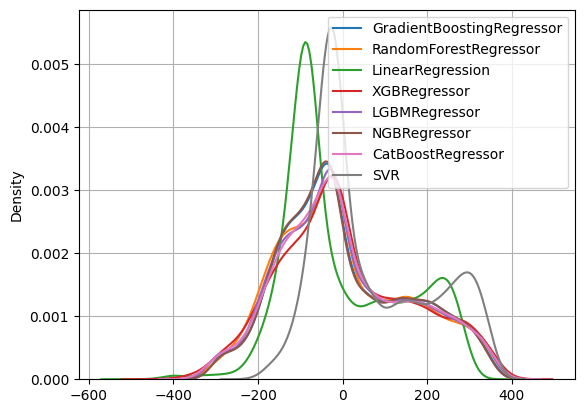

In [77]:
for one_col in df_blending.columns:
  sns.kdeplot(y_test - df_blending[one_col], label=one_col)


plt.legend()
plt.grid()
plt.show()

In [130]:
def calculate_aleatoric_uncertainty(y_true, y_pred):
  n = len(y_true)
  residuals = y_true - y_pred
  aleatoric_uncertainty = np.sum(residuals**2) / n

  return aleatoric_uncertainty


def calculate_epistemic_uncertainty(y_pred_ensemble):
  mean_prediction = np.mean(y_pred_ensemble, axis=0)
  # print(f'mean_prediction: {mean_prediction}; {mean_prediction.shape}')
  m = y_pred_ensemble.shape[0]  # Number of models

  squared_diffs = np.sum((y_pred_ensemble - mean_prediction)**2, axis=0)
  epistemic_uncertainty = squared_diffs / m
  return epistemic_uncertainty

In [120]:
aleatoric_uncertainty = np.mean([calculate_aleatoric_uncertainty(y_test, i) for i in predictions])
epistemic_uncertainty = np.mean(calculate_epistemic_uncertainty(predictions))

In [155]:
aleatoric_uncertainty, epistemic_uncertainty

(12885.860869190874, 1410.1016464217564)

In [133]:
aleatoric_uncertainty + epistemic_uncertainty

14295.962515612631

# model blending
- для домашки : https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html


In [137]:
metrics = cross_val_score(CatBoostRegressor(verbose=False), df_blending, y_test, scoring='neg_mean_squared_error', cv=5)

In [138]:
- np.mean(metrics)

-11151.301562737679

In [148]:
metrics = cross_val_score(
    CatBoostRegressor(verbose=False)
    , pd.concat([df_blending.reset_index(drop=True), X_test.reset_index(drop=True)], axis=1)
    , y_test
    , scoring='neg_mean_squared_error'
    , cv=5
)

In [146]:
- np.mean(metrics)

10762.551698467303

In [152]:
metrics = cross_val_score(
    CatBoostRegressor(verbose=False)
    , X_test.reset_index(drop=True)
    , y_test
    , scoring='neg_mean_squared_error'
    , cv=5
)

In [153]:
- np.mean(metrics)

10968.180715460776